# Eksplorasi Pertemuan 7 — Hidden State & Vanishing Gradient
Visualisasikan bagaimana hidden state RNN merespons deret sinus.

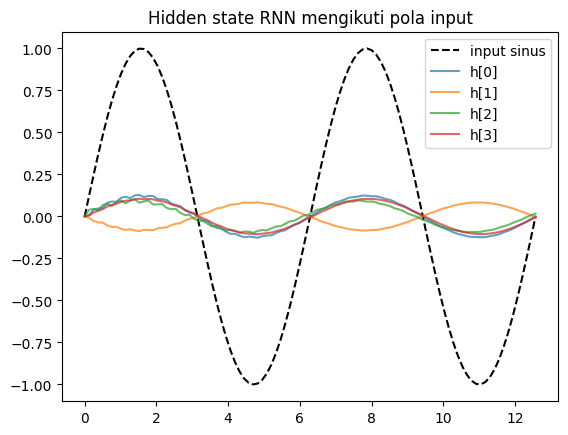

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
from rnn import rnn_forward, demo_vanishing

t = np.linspace(0, 4*np.pi, 100)
sinus = np.sin(t)
rng = np.random.default_rng(0); n = 4
H = rnn_forward(sinus, rng.normal(0, 0.5, n), rng.normal(0, 0.5, (n, n)), np.zeros(n))
plt.plot(t, sinus, "k--", label="input sinus")
for i in range(n):
    plt.plot(t, H[:, i], alpha=0.7, label=f"h[{i}]")
plt.legend(); plt.title("Hidden state RNN mengikuti pola input"); plt.show()

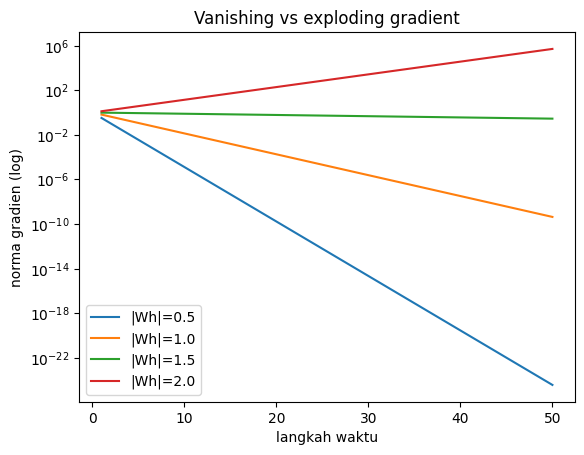

In [2]:
# Kurva vanishing/exploding gradient
langkah = np.arange(1, 51)
for s in [0.5, 1.0, 1.5, 2.0]:
    plt.semilogy(langkah, [demo_vanishing(s, int(k)) for k in langkah], label=f"|Wh|={s}")
plt.xlabel("langkah waktu"); plt.ylabel("norma gradien (log)")
plt.legend(); plt.title("Vanishing vs exploding gradient"); plt.show()

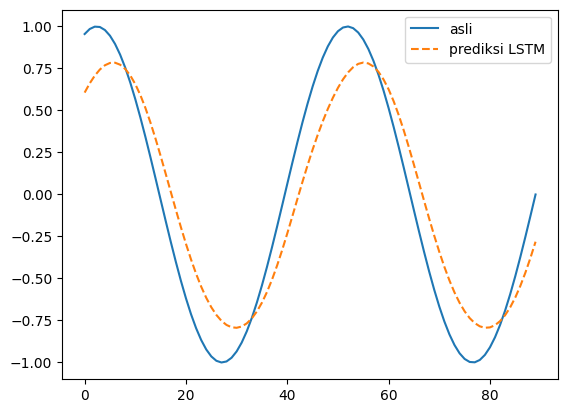

In [3]:
# Opsional — LSTM Keras memprediksi sinus (jalankan di Colab jika TF tak ada)
from tensorflow import keras
from rnn import buat_dataset_window
X, y = buat_dataset_window(sinus, w=10)
X = X[..., None]  # (n, 10, 1)
model = keras.Sequential([
    keras.layers.Input(shape=(10, 1)),
    keras.layers.LSTM(16),
    keras.layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=50, verbose=0)
pred = model.predict(X, verbose=0).ravel()
plt.plot(y, label="asli"); plt.plot(pred, "--", label="prediksi LSTM")
plt.legend(); plt.show()